最小范数解
A = 
 [[1 2 3]
 [4 5 6]]
b = [10 20]
A 的形状: (2, 3), 列数 > 行数 → 无穷多解

最小范数解: [-0.55555556  1.11111111  2.77777778]
验证: Ax = [10. 20.]
范数: ||x|| = 3.0429

np.linalg.lstsq 解: [-0.55555556  1.11111111  2.77777778]
两种方法一致？ True

零空间基: [ 0.40824829 -0.81649658  0.40824829]
另一个解: [ 0.26094103 -0.52188205  3.59427436]
验证: Ax = [10. 20.]
范数: ||x|| = 3.6413 (比最小范数解大)


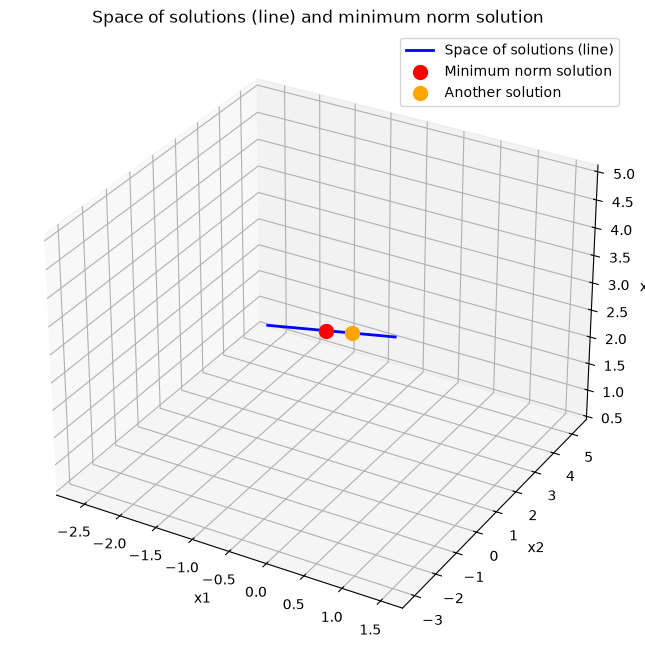

In [1]:
import numpy as np
from scipy.linalg import null_space
import matplotlib.pyplot as plt

# ---- 欠定系统：2个方程，3个未知数 ----
A = np.array([[1, 2, 3], [4, 5, 6]])
b = np.array([10, 20])

print("=" * 60)
print("最小范数解")
print("=" * 60)
print("A = \n", A)
print("b =", b)
print(f"A 的形状: {A.shape}, 列数 > 行数 → 无穷多解")

# ---- 方法1：最小范数解公式 ----
x_min = A.T @ np.linalg.solve(A @ A.T, b)
print(f"\n最小范数解: {x_min}")
print(f"验证: Ax = {A @ x_min}")
print(f"范数: ||x|| = {np.linalg.norm(x_min):.4f}")

# ---- 方法2：np.linalg.lstsq（默认返回最小范数解） ----
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
print(f"\nnp.linalg.lstsq 解: {x_lstsq}")
print(f"两种方法一致？ {np.allclose(x_min, x_lstsq)}")

# ---- 找到另一个解，范数更大 ----
# 零空间的基
ns = null_space(A).flatten()
print(f"\n零空间基: {ns}")

# 添加一个零空间向量
x_another = x_min + 2 * ns
print(f"另一个解: {x_another}")
print(f"验证: Ax = {A @ x_another}")
print(f"范数: ||x|| = {np.linalg.norm(x_another):.4f} (比最小范数解大)")

# ---- 可视化：解空间 ----
# 3D 中，解是一条直线
# 我们画出这条直线上的点
t = np.linspace(-5, 5, 100)
solutions = np.array([x_min + t_i * ns for t_i in t])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(solutions[:, 0], solutions[:, 1], solutions[:, 2], 'b-', linewidth=2, label='解空间 (直线)')
ax.plot(solutions[:, 0], solutions[:, 1], solutions[:, 2], 'b-', linewidth=2, label='Space of solutions (line)')
# ax.scatter(x_min[0], x_min[1], x_min[2], color='red', s=100, label='最小范数解')
ax.scatter(x_min[0], x_min[1], x_min[2], color='red', s=100, label='Minimum norm solution')
# ax.scatter(x_another[0], x_another[1], x_another[2], color='orange', s=100, label='另一个解')
ax.scatter(x_another[0], x_another[1], x_another[2], color='orange', s=100, label='Another solution')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
# ax.set_title('欠定系统的解空间（直线）与最小范数解')
ax.set_title('Space of solutions (line) and minimum norm solution')
ax.legend()
plt.show()